#✅ **Ecommerce Market Insights Analysis**

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv('/content/drive/MyDrive/Dataset/Ecommerce_Dataset_sample.csv')

## ▶ **Initial Data Exploration**




In [18]:
df.head(3) # Top 3 rows of the dataset with columns

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index
0,P6879,Jacket,Apparel,53.85,5,15,150,S535,35-44,"New York, USA",Male,23.32,Standard,4.49,Yes,56
1,P5132,Camera,Electronics,761.26,10,15,224,S583,25-34,"London, UK",Female,20.88,Overnight,16.11,No,79
2,P2941,Sneakers,Footwear,1756.76,5,8,468,S118,25-34,"Tokyo, Japan",Non-Binary,16.43,Standard,4.93,No,40


In [20]:
df.tail(3) # Last 3 rows of the dataset with columns

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index
996,P1652,Comics,Books,1094.35,0,10,126,S265,25-34,"Dubai, UAE",Male,15.69,Express,11.23,No,30
997,P1630,Comics,Books,1038.83,20,12,155,S568,45-54,"Dubai, UAE",Female,46.74,Overnight,11.16,No,86
998,P7059,Tablet,Electronics,172.37,25,12,239,S140,45-54,"Houston, USA",Female,17.06,Standard,11.11,No,43


In [22]:
df.shape # 999:Rows & 16:Columns in the dataset

(999, 16)

In [23]:
df.columns # Names of the Columns

Index(['Product ID', 'Product Name', 'Category', 'Price', 'Discount',
       'Tax Rate', 'Stock Level', 'Supplier ID', 'Customer Age Group',
       'Customer Location', 'Customer Gender', 'Shipping Cost',
       'Shipping Method', 'Return Rate', 'Seasonality', 'Popularity Index'],
      dtype='object')

In [28]:
# Information about the Null-Values and the Data-types of each column of the dataset.

df.info() # RangeIndex: 999 entries, 0 to 998

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product ID          999 non-null    object 
 1   Product Name        999 non-null    object 
 2   Category            999 non-null    object 
 3   Price               999 non-null    float64
 4   Discount            999 non-null    int64  
 5   Tax Rate            999 non-null    int64  
 6   Stock Level         999 non-null    int64  
 7   Supplier ID         999 non-null    object 
 8   Customer Age Group  999 non-null    object 
 9   Customer Location   999 non-null    object 
 10  Customer Gender     999 non-null    object 
 11  Shipping Cost       999 non-null    float64
 12  Shipping Method     999 non-null    object 
 13  Return Rate         999 non-null    float64
 14  Seasonality         999 non-null    object 
 15  Popularity Index    999 non-null    int64  
dtypes: float

In [29]:
df.describe() # analyze numeric columns and returns a data frame containing 8 statistical metrics.

,Price,Discount,Tax Rate,Stock Level,Shipping Cost,Return Rate,Popularity Index
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,1038.509499,12.322322,10.027027,252.862863,24.650851,10.734364,49.424424
std,584.805840,8.795848,3.367931,141.914812,14.528778,5.427911,28.302758
min,13.000000,0.000000,5.000000,0.000000,0.010000,1.030000,0.000000
25%,517.815000,5.000000,8.000000,135.000000,12.510000,6.095000,25.000000
50%,1055.720000,10.000000,10.000000,252.000000,24.440000,10.530000,51.000000
75%,1566.560000,20.000000,12.000000,376.500000,37.085000,15.625000,72.500000
max,1996.700000,25.000000,15.000000,500.000000,49.990000,19.970000,100.000000


## ▶ **Data Cleaning**

In [30]:
df.isnull().sum() # Check the missing values(Null-values)
# There are no missing values.

,0
Product ID,0
Product Name,0
Category,0
Price,0
Discount,0
Tax Rate,0
Stock Level,0
Supplier ID,0
Customer Age Group,0
Customer Location,0


In [32]:
df.duplicated().sum() # Duplicate Records

np.int64(0)

In [34]:
df.drop_duplicates(inplace=True) # Remove Duplicates

## ⚓ **Exploratory Data Analysis** ▶

---

### **Analysis 1 - Product Category Distribution**

Question: Which category has the highest number of products?




In [47]:
df['Category'].value_counts()

,count
Category,
Books,215
Electronics,208
Home Appliances,207
Footwear,186
Apparel,183


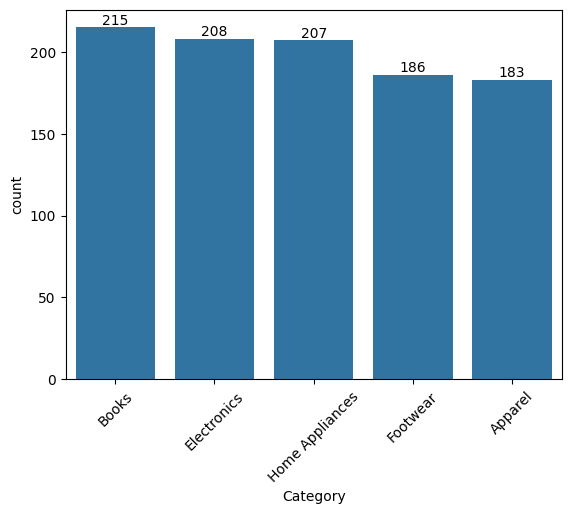

In [52]:
# 1. Get the order of categories from highest to lowest count
category_order = df['Category'].value_counts().index

# 2. Pass that order into the countplot
ax = sns.countplot(data=df, x='Category', order=category_order)

# 3. Add the labels on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.show()

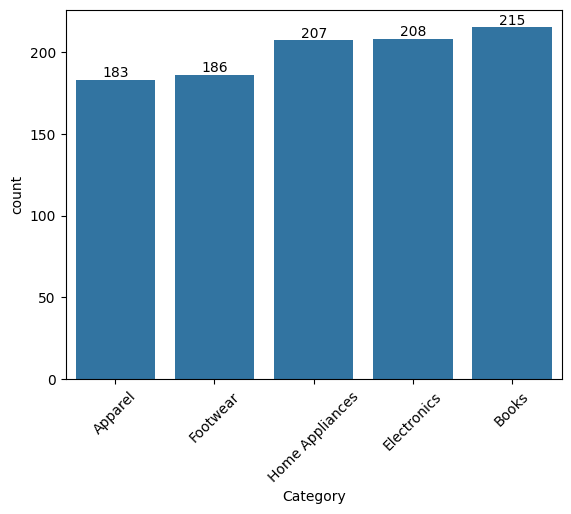

In [55]:
# Sorted from lowest count to highest count
ascending_order = df['Category'].value_counts().index[::-1]

ax = sns.countplot(data=df, x='Category', order=ascending_order)

# Add the labels on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.show()

### **Analysis 2 - Average Product Price by Category**
Which category has the most expensive products?

In [56]:
df.groupby('Category')['Price'].mean().sort_values(ascending=False)

,Price
Category,
Footwear,1074.742581
Home Appliances,1058.465556
Books,1048.508093
Apparel,1014.398579
Electronics,997.126538


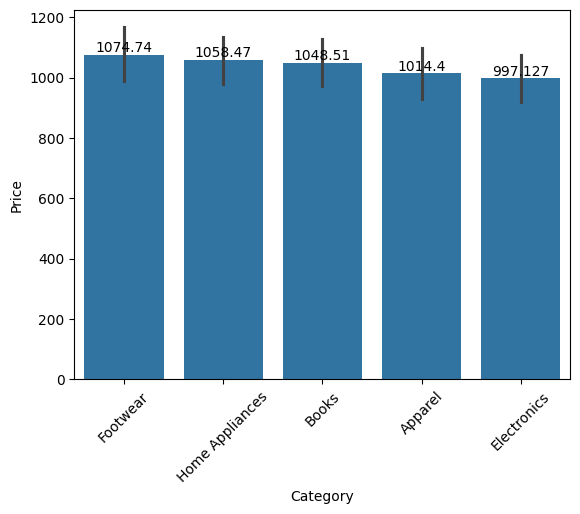

In [66]:
# 1. Calculate the mean price per category and sort in descending order
bar_order = df.groupby('Category')['Price'].mean().sort_values(ascending=False).index

# 2. Pass that sorted index into the 'order' argument
ax = sns.barplot(data=df, x='Category', y='Price', order=bar_order)

# 3. (Optional) Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.show()

### **Analysis 3 - Discount Analysis**

Which categories offer the highest discounts?

In [67]:
df.groupby('Category')['Discount'].mean()

,Discount
Category,
Apparel,13.224044
Books,12.000000
Electronics,12.091346
Footwear,12.607527
Home Appliances,11.835749


### Analysis 4 - Customer Age Group Analysis

Which age group purchases most frequently?

In [68]:
df['Customer Age Group'].value_counts()

,count
Customer Age Group,
55+,228
35-44,210
45-54,206
25-34,185
18-24,170


<Axes: xlabel='Customer Age Group', ylabel='count'>

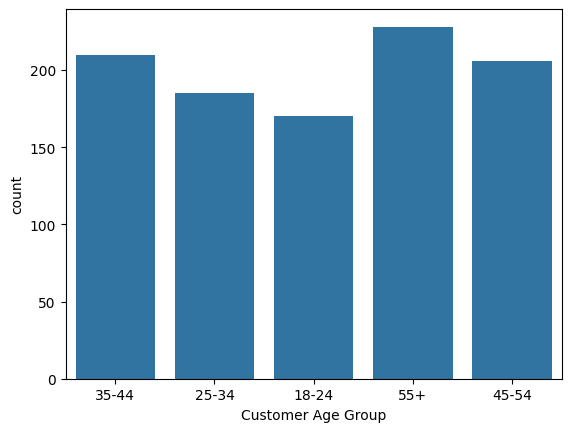

In [69]:
sns.countplot(
    data=df,
    x='Customer Age Group'
)

### **Analysis 5 - Customer Gender Analysis**

What is the customer gender distribution?

In [70]:
df['Customer Gender'].value_counts()

,count
Customer Gender,
Female,347
Male,328
Non-Binary,324


<Axes: ylabel='count'>

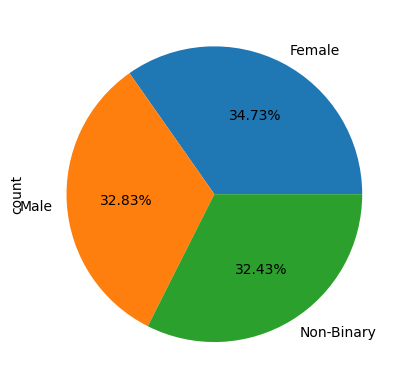

In [82]:
# Pie Chart

df['Customer Gender'].value_counts().plot(
    kind='pie', autopct='%1.2f%%') # autopct - Its job is to automatically calculate the percentage for each slice of the pie

### **Analysis 6 - Customer Location Analysis**

Which locations have the most customers?

In [83]:
df['Customer Location'].value_counts()

,count
Customer Location,
"Cape Town, South Africa",79
Singapore,77
"London, UK",76
"Phoenix, USA",74
"Houston, USA",69
"Paris, France",68
"Toronto, Canada",68
"Tokyo, Japan",67
"Mumbai, India",63


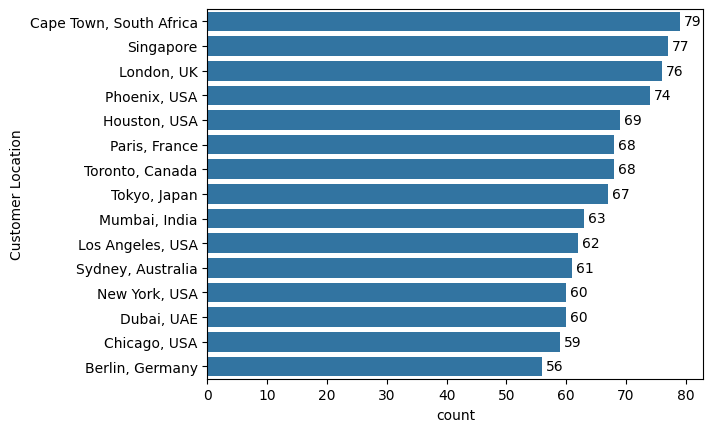

In [87]:
# 1. Get the order of locations from highest to lowest count
location_order = df['Customer Location'].value_counts().index

# 2. Pass that order into the countplot (keeping y='Customer Location')
ax = sns.countplot(data=df, y='Customer Location', order=location_order)

# 3. Add the count labels to the end of each horizontal bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

### **Analysis 7 - Shipping Method Analysis**

Which shipping method is preferred?

In [89]:
df['Shipping Method'].value_counts()

,count
Shipping Method,
Standard,360
Overnight,324
Express,315


### **Analysis 8 - Return Rate Analysis**

Which category has the highest return rate?

In [92]:
df.groupby('Category')['Return Rate'].mean()

,Return Rate
Category,
Apparel,10.717596
Books,9.981721
Electronics,10.755000
Footwear,10.712043
Home Appliances,11.530242


### **Analysis 9 - Seasonality Analysis**
Do seasonal products have higher popularity?

In [93]:
df.groupby('Seasonality')['Popularity Index'].mean()

,Popularity Index
Seasonality,
No,48.867063
Yes,49.991919


### **Analysis 10 - Popularity Analysis**

**Top 10 most popular products**

In [3]:
top_products = (
    df.groupby('Product Name')['Popularity Index']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

In [4]:
print(top_products)

Product Name
Smartphone      66.823529
Hiking Shoes    62.300000
Flats           60.000000
Speaker         59.840000
Microwave       59.500000
Cookbooks       59.000000
Monitor         58.047619
Comics          56.354839
Headphones      55.962963
Fiction         55.740741
Name: Popularity Index, dtype: float64


<Axes: xlabel='Product Name'>

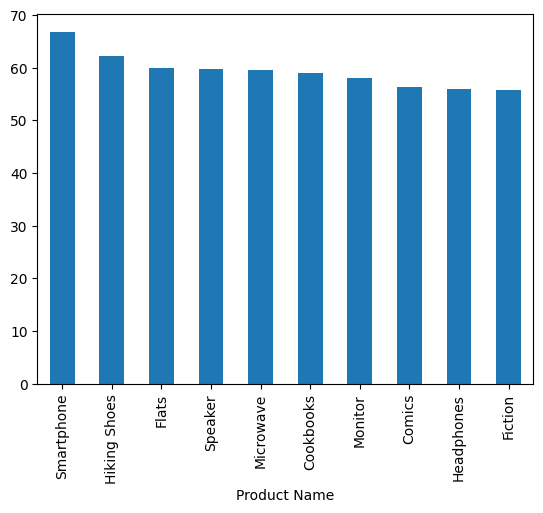

In [5]:
top_products.plot(kind='bar')

### **Analysis 11 - Stock Level Analysis**

Which categories have the highest stock?

In [6]:
df.groupby('Category')['Stock Level'].mean()

,Stock Level
Category,
Apparel,254.442623
Books,247.093023
Electronics,271.341346
Footwear,244.500000
Home Appliances,246.405797


## ▶ **Analysis 12 - Correlation Analysis**

<Axes: >

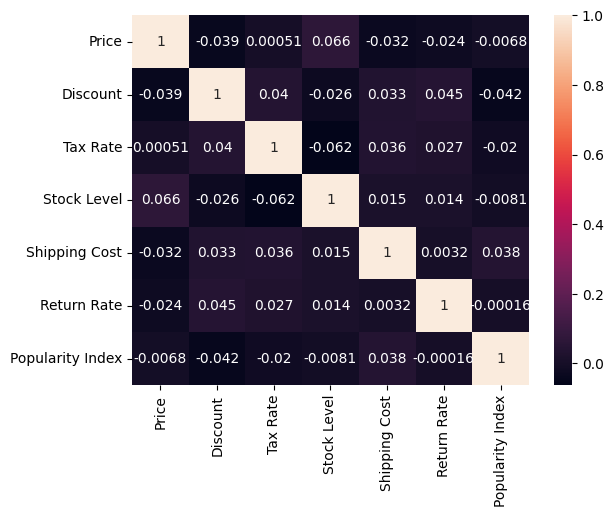

In [8]:
numeric_cols = [
    'Price',
    'Discount',
    'Tax Rate',
    'Stock Level',
    'Shipping Cost',
    'Return Rate',
    'Popularity Index'
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True
)